# Exploratory Data Analysis of the Data

## Overview
This is tabular data for the HECKTOR Challenge 2026, its main use will be for completing Tasks 2 and 3. Hence, we need to make sure that the data is prepped for the following:
- Task 2: Predict TN-Staging
- Task 3: Predict recurrence-free survival

In layman terms, we need it to be prepared to fit some form of neural network or machine learning algorithm so that we can predict those two things.

## Exploring the Dataset As It Is

In [1]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import joblib
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

sns.set_style("darkgrid")

In [2]:
# Importing the dataset

df = pd.read_csv("./Data/HECKTOR_2026_training_data.csv")
df.head()

,PatientID,CenterID,Age,Gender,Tobacco Consumption,Alcohol Consumption,Performance Status,Treatment,HPV Status,Relapse,RFS,T-stage,N-stage
0,CHUM-001,1.0,82.0,1.0,NaN,NaN,NaN,1.0,NaN,0.0,1704.0,T2,N2
1,CHUM-002,1.0,73.0,1.0,NaN,NaN,NaN,1.0,NaN,1.0,439.0,T3,N1
2,CHUM-006,1.0,65.0,1.0,NaN,NaN,NaN,1.0,NaN,0.0,1186.0,T2,N2
3,CHUM-007,1.0,70.0,0.0,NaN,NaN,NaN,0.0,NaN,0.0,1702.0,T2,N2
4,CHUM-008,1.0,67.0,0.0,NaN,NaN,NaN,1.0,NaN,0.0,1499.0,T2,N2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PatientID            782 non-null    object 
 1   CenterID             782 non-null    float64
 2   Age                  782 non-null    float64
 3   Gender               782 non-null    float64
 4   Tobacco Consumption  522 non-null    float64
 5   Alcohol Consumption  516 non-null    float64
 6   Performance Status   468 non-null    float64
 7   Treatment            763 non-null    float64
 8   HPV Status           597 non-null    float64
 9   Relapse              727 non-null    float64
 10  RFS                  727 non-null    float64
 11  T-stage              778 non-null    object 
 12  N-stage              782 non-null    object 
dtypes: float64(10), object(3)
memory usage: 79.6+ KB


Looking at this dataset's columns, we can see that our target features would be the following:
- Task 2:
    1. T-Stage
    2. N-Stage
- Task 3:
    1. Relapse (did the cancer come back? 0 or 1)
    2. RFS (how many days until relapse or last follow-up)

For Task 3 you need **both** Relapse and RFS together. That is the classic survival analysis setup (event + time). Relapse alone does not tell the whole story.

In [4]:
df.describe()

,CenterID,Age,Gender,Tobacco Consumption,Alcohol Consumption,Performance Status,Treatment,HPV Status,Relapse,RFS
count,782.000000,782.000000,782.000000,522.000000,516.000000,468.000000,763.000000,597.000000,727.000000,727.000000
mean,4.335038,59.987468,0.835038,0.461686,0.637597,0.621795,0.836173,0.892797,0.203576,1638.778542
std,1.514006,9.211646,0.371383,0.499008,0.481161,0.725872,0.370361,0.309630,0.402935,1200.289138
min,1.000000,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000
25%,3.000000,53.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,715.000000
50%,5.000000,59.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1295.000000
75%,5.000000,66.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,2545.500000
max,8.000000,90.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,1.000000,5888.000000


In [5]:
print(df.isnull().sum())

PatientID                0
CenterID                 0
Age                      0
Gender                   0
Tobacco Consumption    260
Alcohol Consumption    266
Performance Status     314
Treatment               19
HPV Status             185
Relapse                 55
RFS                     55
T-stage                  4
N-stage                  0
dtype: int64


In [6]:
df.shape

(782, 13)

As we can see, a fair number of missing values in the dataset, and a lot of data that seems to be normalized from 0 to 1 already. This might also be a case where its a categorical column, but the float dtype and the missing values might be messing with the mean. I need to figure out which columns are categorical and switch them out.

In [7]:
df.nunique()

PatientID              782
CenterID                 8
Age                     63
Gender                   2
Tobacco Consumption      2
Alcohol Consumption      2
Performance Status       5
Treatment                2
HPV Status               2
Relapse                  2
RFS                    648
T-stage                  5
N-stage                  4
dtype: int64

Ok, so we can see there are a lot of categorical columns in this. We need to make sure we can preprocess this later so that it's treated as categorical. 

## Cleaning the Dataset

Alright, we have poked around enough. Time to actually clean this up. We are going from a raw CSV to something a model can use.

Quick checklist:
- IDs are not duplicated
- Labels look valid (T1-T4, N0-N3, etc.)
- Missing values have a plan (fill features, drop bad label rows)
- Separate datasets for Tasks 2 and 3

Let's go.

In [8]:
# Column roles, easy to remember and access this way
ID_COL = "PatientID"

FEATURE_COLS = [
    "CenterID", "Age", "Gender", "Tobacco Consumption",
    "Alcohol Consumption", "Performance Status", "Treatment", "HPV Status",
]
CAT_COLS = [c for c in FEATURE_COLS if c != "Age"]  # Literally all the features are categorical except for Age

T_LABEL = "T-stage"
N_LABEL = "N-stage"
EVENT_COL = "Relapse"
TIME_COL = "RFS"

VALID_T = ["T0", "T1", "T2", "T3", "T4"]  # include T0 as a valid stage label
VALID_N = ["N0", "N1", "N2", "N3"]

print("Features:", FEATURE_COLS)
print("Task 2 labels:", T_LABEL, N_LABEL)
print("Task 3 labels:", EVENT_COL, TIME_COL)

Features: ['CenterID', 'Age', 'Gender', 'Tobacco Consumption', 'Alcohol Consumption', 'Performance Status', 'Treatment', 'HPV Status']
Task 2 labels: T-stage N-stage
Task 3 labels: Relapse RFS


`PatientID` is just an ID. We do not feed it to a model. We also do not impute labels (you cannot guess someone's T-stage). If a label is missing, that row gets dropped for that task. Features, on the other hand, we will fill in.

In [9]:
# Check patient IDs
df[ID_COL] = df[ID_COL].astype(str).str.strip()

# Strip whitespace on stage labels (keep NaN as NaN)
for col in [T_LABEL, N_LABEL]:
    not_missing = df[col].notna()
    df.loc[not_missing, col] = df.loc[not_missing, col].astype(str).str.strip()

dup_count = df[ID_COL].duplicated().sum()
print("Duplicate PatientIDs:", dup_count)

Duplicate PatientIDs: 0


In [10]:
# Check labels look reasonable

print("=== Label counts ===\n")
for col in [T_LABEL, N_LABEL, EVENT_COL]:
    print(col)
    print(df[col].value_counts(dropna=False))
    print()

print("\n=== Sanity checks ===")
print("Negative RFS:", (df[TIME_COL] < 0).sum())

bad_relapse = df[EVENT_COL].notna() & ~df[EVENT_COL].isin([0, 1])
print("Bad Relapse values:", bad_relapse.sum())

print("Missing Relapse:", df[EVENT_COL].isna().sum())
print("Missing RFS:", df[TIME_COL].isna().sum())
print("Missing together:", df[EVENT_COL].isna().equals(df[TIME_COL].isna()))

=== Label counts ===

T-stage
T-stage
T2     285
T1     189
T3     183
T4     118
NaN      4
T0       3
Name: count, dtype: int64

N-stage
N-stage
N2    471
N3    148
N0     87
N1     76
Name: count, dtype: int64

Relapse
Relapse
0.0    579
1.0    148
NaN     55
Name: count, dtype: int64


=== Sanity checks ===
Negative RFS: 0
Bad Relapse values: 0
Missing Relapse: 55
Missing RFS: 55
Missing together: True


/var/folders/qw/y3ys43gs7cdblx18lvtrz8r40000gn/T/ipykernel_14300/2935510397.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([has_t, missing_t], labels=['Has T-stage', 'Missing T-stage'])


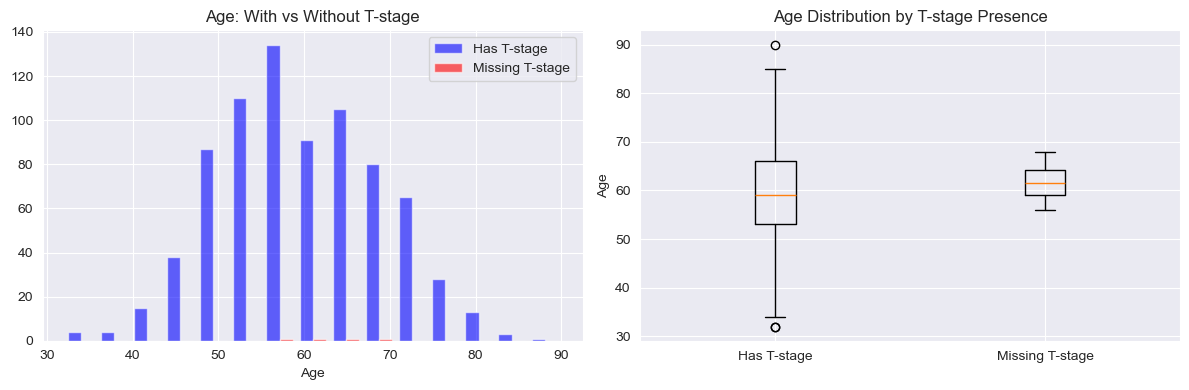

In [11]:
# Missing-target comparison: Age distribution for rows with vs without T-stage
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

has_t = df[df[T_LABEL].notna()]['Age']
missing_t = df[df[T_LABEL].isna()]['Age']

axes[0].hist([has_t, missing_t], label=['Has T-stage', 'Missing T-stage'], bins=15, color=['blue', 'red'], alpha=0.6)
axes[0].set_title('Age: With vs Without T-stage')
axes[0].set_xlabel('Age')
axes[0].legend()

# Boxplot comparison
axes[1].boxplot([has_t, missing_t], labels=['Has T-stage', 'Missing T-stage'])
axes[1].set_title('Age Distribution by T-stage Presence')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

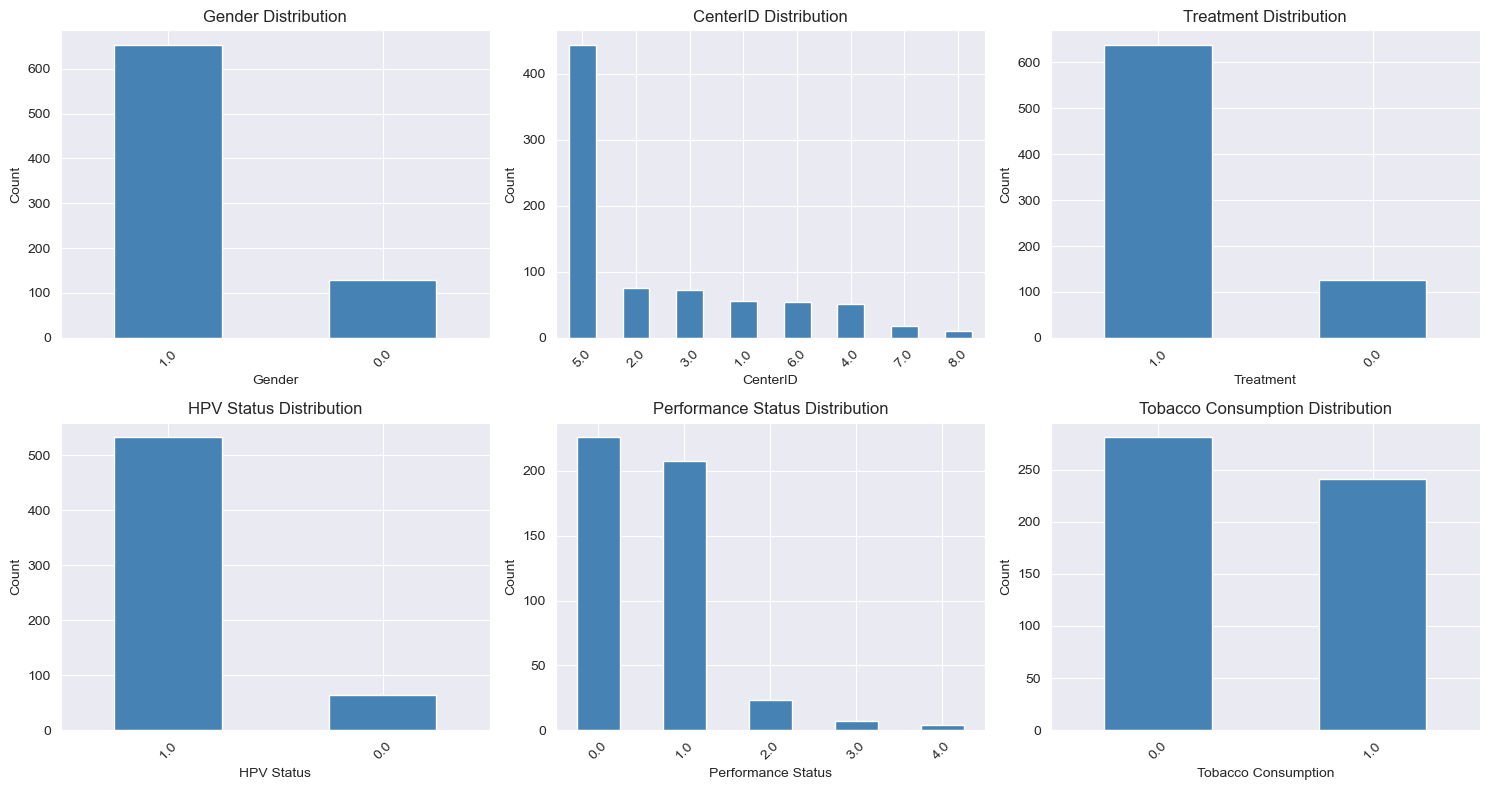

In [12]:
# Categorical feature distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

cat_features = ['Gender', 'CenterID', 'Treatment', 'HPV Status', 'Performance Status', 'Tobacco Consumption']

for idx, col in enumerate(cat_features):
    df[col].value_counts().plot(kind='bar', ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'{col} Distribution')
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

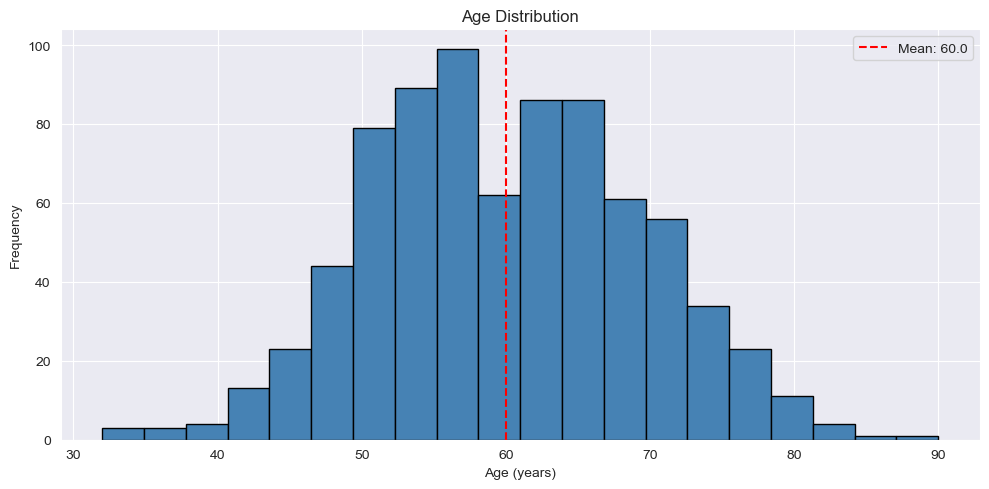

In [13]:
# Age histogram
plt.figure(figsize=(10, 5))
plt.hist(df['Age'].dropna(), bins=20, color='steelblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age (years)')
plt.ylabel('Frequency')
plt.axvline(df['Age'].mean(), color='red', linestyle='--', label=f"Mean: {df['Age'].mean():.1f}")
plt.legend()
plt.tight_layout()
plt.show()

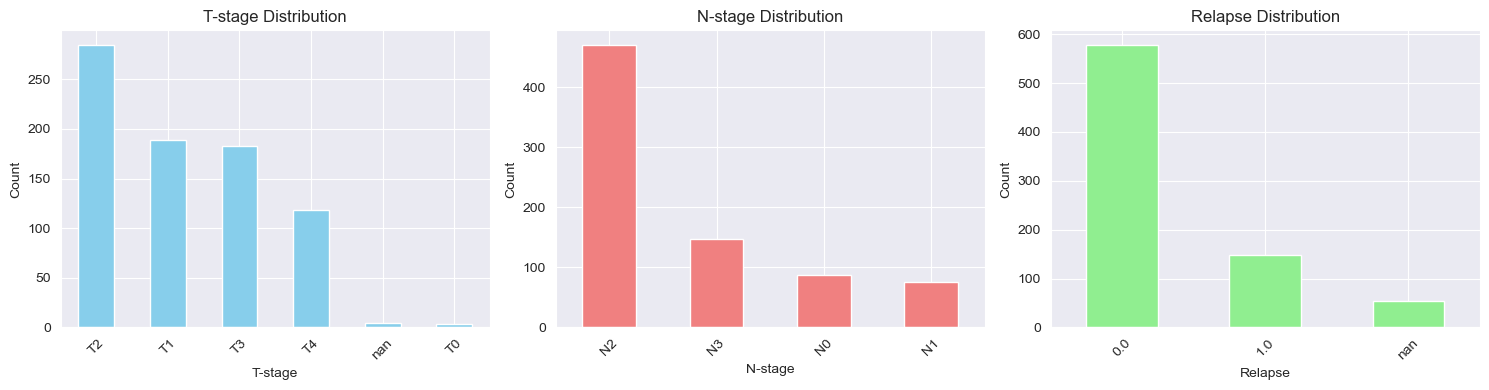

In [14]:
# Target label distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# T-stage
df[T_LABEL].value_counts(dropna=False).plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('T-stage Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# N-stage
df[N_LABEL].value_counts(dropna=False).plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('N-stage Distribution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# Relapse
df[EVENT_COL].value_counts(dropna=False).plot(kind='bar', ax=axes[2], color='lightgreen')
axes[2].set_title('Relapse Distribution')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

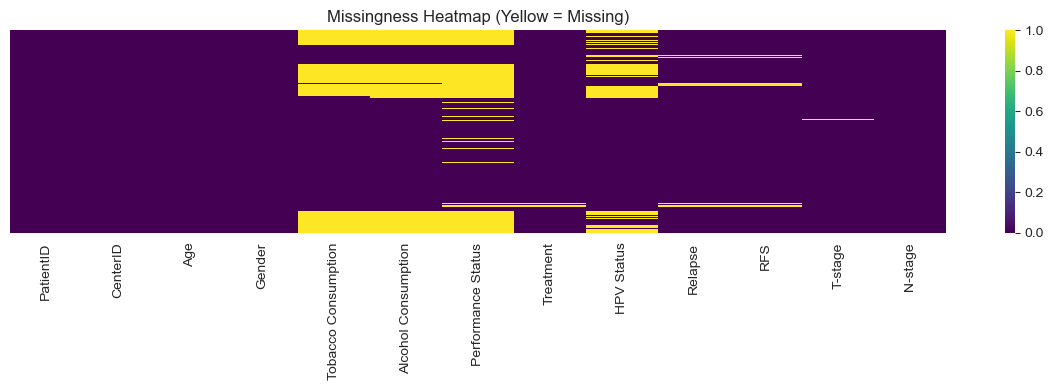

In [15]:
# Missingness heatmap, shows patterns across rows
plt.figure(figsize=(12, 4))
sns.heatmap(df.isna(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missingness Heatmap (Yellow = Missing)')
plt.tight_layout()
plt.show()

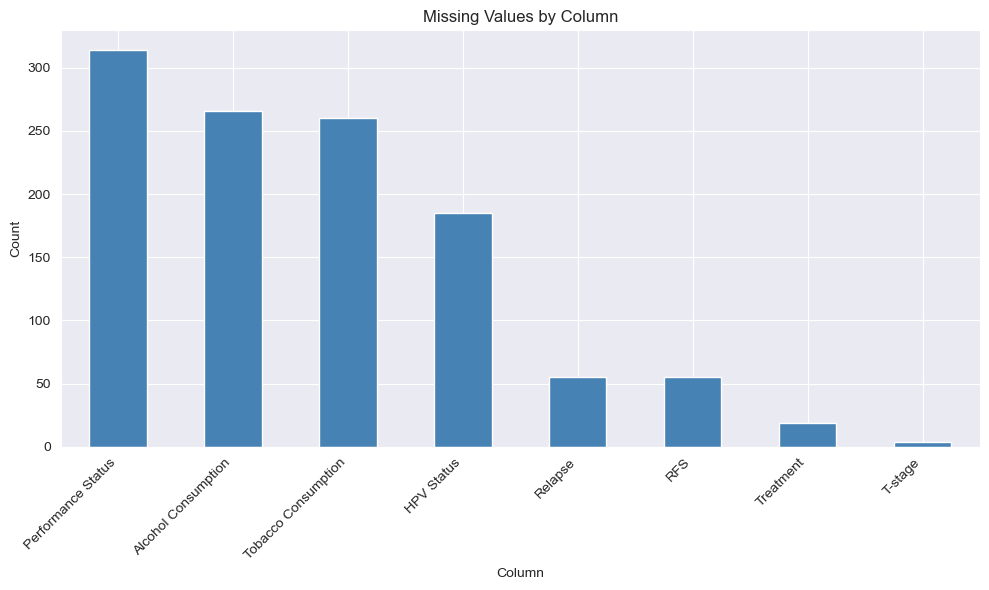

In [16]:
# Missing values bar chart
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]  # Only show columns with missing values

plt.figure(figsize=(10, 6))
missing.plot(kind='bar', color='steelblue')
plt.title('Missing Values by Column')
plt.xlabel('Column')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Data Quality Visualizations

Let's visualize the data quality issues and distributions to understand what we're cleaning.

Yes, a lot of these columns are float64 in the CSV, so we will just make them categorical. 

In [17]:
# Mark categorical columns (Age stays numeric)
for col in CAT_COLS:
    df[col] = df[col].astype("category")

print(df[CAT_COLS].dtypes)

CenterID               category
Gender                 category
Tobacco Consumption    category
Alcohol Consumption    category
Performance Status     category
Treatment              category
HPV Status             category
dtype: object


In [18]:
# Fill missing feature values with -1 (means unknown)
df_clean = df.copy()

for col in CAT_COLS:
    df_clean[col] = df_clean[col].astype(float).fillna(-1)

df_clean.isnull().sum()

PatientID               0
CenterID                0
Age                     0
Gender                  0
Tobacco Consumption     0
Alcohol Consumption     0
Performance Status      0
Treatment               0
HPV Status              0
Relapse                55
RFS                    55
T-stage                 4
N-stage                 0
dtype: int64

In [19]:
# Build one dataframe per task without discarding target-label rows up front.
# We will handle missing target values later via the planned clustering + cluster-mean imputation.
df_tn = df_clean.copy()
df_rfs = df_clean.copy()

# Keep only expected stage labels for the T/N task view, but do not remove rows with missing targets yet.
valid_rows = df_tn[T_LABEL].isin(VALID_T) & df_tn[N_LABEL].isin(VALID_N)
invalid_count = (~valid_rows).sum()
df_tn = df_tn[valid_rows].copy()

print("Original rows:", len(df_clean))
print("Task 2 rows:", len(df_tn))
print("  missing T-stage:", df_clean[T_LABEL].isna().sum())
print("  missing N-stage:", df_clean[N_LABEL].isna().sum())
print("  invalid T/N stage rows removed:", invalid_count)
print("Task 3 rows:", len(df_rfs))
print("  missing Relapse:", df_clean[EVENT_COL].isna().sum())
print("  missing RFS:", df_clean[TIME_COL].isna().sum())

Original rows: 782
Task 2 rows: 778
  missing T-stage: 4
  missing N-stage: 0
  invalid T/N stage rows removed: 4
Task 3 rows: 782
  missing Relapse: 55
  missing RFS: 55


In [20]:
import os
# Save cleaned files
os.makedirs("./Data", exist_ok=True)

df_clean.to_csv("./Data/HECKTOR_2026_training_clean.csv", index=False)
df_tn.to_csv("./Data/task2_clean.csv", index=False)
df_rfs.to_csv("./Data/task3_clean.csv", index=False)

print("Saved cleaned CSV files to ./Data/")

Saved cleaned CSV files to ./Data/


### Cleaning recap

- **IDs:** stripped whitespace, checked for duplicates
- **Labels:** validated T/N stages and Relapse/RFS; dropped rows with missing labels per task
- **Invalid stages:** removed rows outside expected T1-T4 / N0-N3 (e.g. T0)
- **Features:** categorical columns filled with `-1` when missing (means unknown)
- **Outputs:** three CSVs saved in `./Data/`

Next up: preprocessing, turning this into numbers a model can use.

## Preprocessing

Alright, firstly, we have to find the right missing values for the target features. We can do this by first clustering (K-means), finding the missing target's closest cluster centre, and then inferring the target data point from there.


Selected k: 2


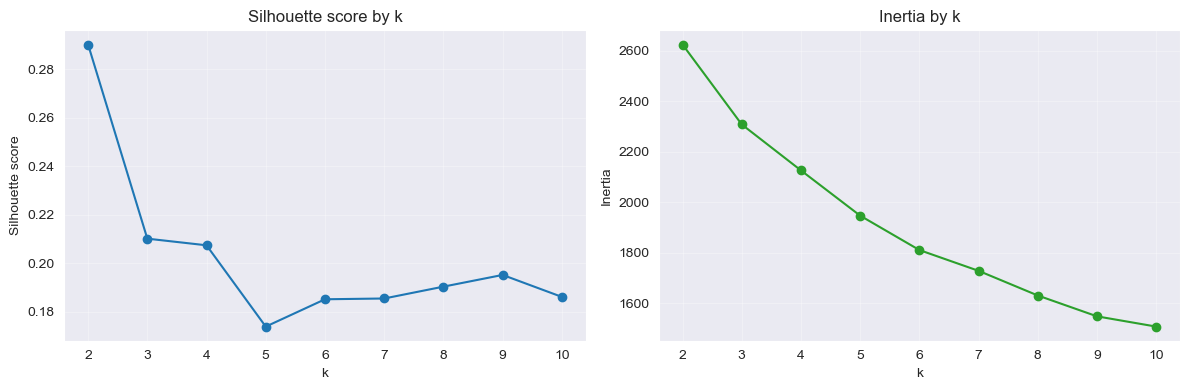

In [21]:
# Build the clustering matrix and choose k by silhouette score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def build_cluster_matrix(df, numeric_cols, categorical_cols):
    numeric = df[numeric_cols].astype(float)
    numeric = StandardScaler().fit_transform(numeric)

    categorical = df[categorical_cols].fillna('Missing').astype(str)
    categorical = OneHotEncoder(handle_unknown='ignore', sparse_output=False).fit_transform(categorical)

    return np.hstack([numeric, categorical])

cluster_cols = CAT_COLS
X_cluster = build_cluster_matrix(df_clean, ['Age'], cluster_cols)

k_values = list(range(2, 11))
scores = []
for k in k_values:
    labels = KMeans(n_clusters=k, random_state=42, n_init=20).fit_predict(X_cluster)
    scores.append(silhouette_score(X_cluster, labels))

best_k = k_values[int(np.argmax(scores))]
print('Selected k:', best_k)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(k_values, scores, marker='o', color='tab:blue')
ax[0].set_title('Silhouette score by k')
ax[0].set_xlabel('k')
ax[0].set_ylabel('Silhouette score')
ax[0].grid(alpha=0.3)

inertia = []
for k in k_values:
    inertia.append(KMeans(n_clusters=k, random_state=42, n_init=20).fit(X_cluster).inertia_)

ax[1].plot(k_values, inertia, marker='o', color='tab:green')
ax[1].set_title('Inertia by k')
ax[1].set_xlabel('k')
ax[1].set_ylabel('Inertia')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [22]:
# Fit KMeans and impute missing targets cleanly
# from sklearn.cluster import KMeans
# from sklearn.neighbors import KNeighborsRegressor
# from sklearn.preprocessing import StandardScaler

# def mode_or_nan(series):
#     values = series.dropna()
#     return values.mode().iloc[0] if len(values) else np.nan

# def impute_rfs_knn(df, features, target='RFS', n_neighbors=5, weights='distance'):
#     result = df.copy()
#     missing = result[target].isna()
#     if not missing.any():
#         return result

#     X = StandardScaler().fit_transform(features)
#     X_train = X[~missing]
#     y_train = result.loc[~missing, target].astype(float)
#     X_missing = X[missing]

#     knn = KNeighborsRegressor(
#         n_neighbors=min(n_neighbors, len(y_train)),
#         weights=weights,
#     )
#     knn.fit(X_train, y_train)
#     result.loc[missing, target] = knn.predict(X_missing)
#     return result

# cluster_model = KMeans(n_clusters=best_k, random_state=42, n_init=20)
# df_clean['cluster'] = cluster_model.fit_predict(X_cluster)

# for target in ['T-stage', 'N-stage', 'Relapse']:
#     missing = df_clean[target].isna()
#     if missing.any():
#         cluster_modes = (
#             df_clean.loc[~missing]
#             .groupby('cluster')[target]
#             .agg(mode_or_nan)
#         )
#         df_clean.loc[missing, target] = df_clean.loc[missing, 'cluster'].map(cluster_modes)


## Statistical Analysis to Understand the Data

Exploratory summary by relapse status
         patients  mean_age  median_rfs
Relapse                                
0.0           579     60.03      1596.0
1.0           148     60.12       399.5
NaN            55     59.22         NaN

Stage distributions
T-stage
T2     285
T1     189
T3     183
T4     118
NaN      4
T0       3


N-stage
N2    471
N3    148
N0     87
N1     76


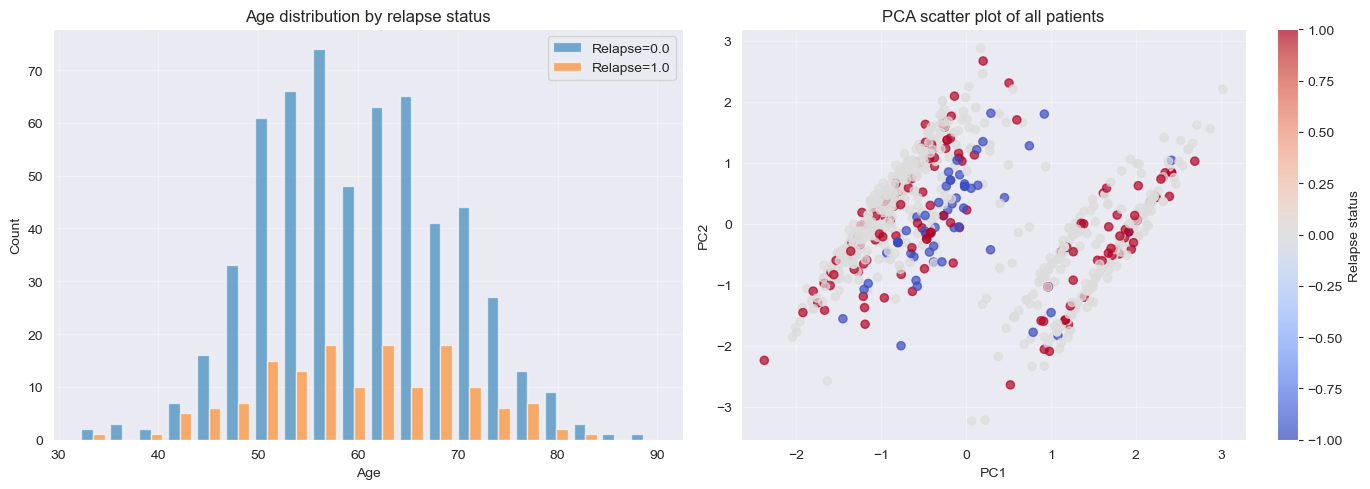

In [23]:
# Analysis section: summary tables and a full-data scatter view
from sklearn.decomposition import PCA


# Build one feature matrix for exploratory visualization.
def build_analysis_matrix(frame):
    age = frame[["Age"]].astype(float)
    age_scaled = StandardScaler().fit_transform(age)

    cat = frame[CAT_COLS].fillna("Missing").astype(str)
    cat_encoded = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit_transform(cat)

    return np.hstack([age_scaled, cat_encoded])


X_analysis = build_analysis_matrix(df_clean)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_analysis)

print("Exploratory summary by relapse status")
print(
    df_clean.groupby("Relapse", dropna=False)
    .agg(
        patients=("PatientID", "count"),
        mean_age=("Age", "mean"),
        median_rfs=("RFS", "median"),
    )
    .round(2)
    .to_string()
)

print("\nStage distributions")
print(df_clean["T-stage"].value_counts(dropna=False).to_string())
print("\n")
print(df_clean["N-stage"].value_counts(dropna=False).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: age distribution by relapse status.
relapse_groups = [df_clean.loc[df_clean["Relapse"] == value, "Age"] for value in sorted(df_clean["Relapse"].dropna().unique())]
axes[0].hist(relapse_groups, bins=20, label=[f"Relapse={value}" for value in sorted(df_clean["Relapse"].dropna().unique())], alpha=0.6)
axes[0].set_title("Age distribution by relapse status")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: PCA scatter plot of the full dataset.
scatter = axes[1].scatter(
    coords[:, 0],
    coords[:, 1],
    c=df_clean["Relapse"].fillna(-1),
    cmap="coolwarm",
    s=35,
    alpha=0.7,
)
axes[1].set_title("PCA scatter plot of all patients")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1], label="Relapse status")

plt.tight_layout()
plt.show()

In [24]:
# Alright, clustering may not be the best imputation method for T/N stage, but it seems to have done a reasonable job with RFS. Let's save the imputed dataset for future modeling.

# Instead, here is the plan:
# 1. We remove the missing values temporarily for each data. Then, we build a model to predict that target feature by splitting the remaining data into train/test sets. We can use a simple model like logistic regression for T/N stage and linear regression for RFS, or even a more complex model if we want.
# 2. We evaluate the model's performance on the test set to ensure it's reasonably accurate
# 3. If the model performs well, we use it to predict the missing target values and fill them in.

# Prepare datasets for Task 2 (T-stage and N-stage prediction)
df_task2 = df_clean[df_clean[T_LABEL].notna() & df_clean[N_LABEL].notna()].copy()

# Prepare dataset for Task 3 (RFS prediction)
df_task3 = df_clean[df_clean[TIME_COL].notna()].copy()

# Features for modeling (exclude ID, targets, and cluster)
feature_cols_model = FEATURE_COLS

print(f"Task 2 dataset: {len(df_task2)} rows with valid T and N stages")
print(f"Task 3 dataset: {len(df_task3)} rows with valid RFS")
print(f"Features used: {feature_cols_model}")

Task 2 dataset: 778 rows with valid T and N stages
Task 3 dataset: 727 rows with valid RFS
Features used: ['CenterID', 'Age', 'Gender', 'Tobacco Consumption', 'Alcohol Consumption', 'Performance Status', 'Treatment', 'HPV Status']


In [25]:
# Alright, lets split the Task 2 dataset into train/test sets and build a simple model to predict T-stage and N-stage. We will use SVC for this, and evaluate the performance using accuracy and classification reports. Then we can use the trained model to impute missing T/N stages in the full dataset.

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Prepare features and labels for T-stage prediction
X_t = df_task2[feature_cols_model]
y_t = df_task2[T_LABEL]

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_t, y_t, test_size=0.2, random_state=42)

# Train SVC for T-stage prediction
model_t = SVC(kernel='rbf', random_state=42)
model_t.fit(X_train_t, y_train_t)

# Evaluate T-stage model
y_pred_t = model_t.predict(X_test_t)
print("T-stage Prediction Performance:")
print(classification_report(y_test_t, y_pred_t))
print("T-stage Accuracy:", accuracy_score(y_test_t, y_pred_t))


T-stage Prediction Performance:
              precision    recall  f1-score   support

          T0       0.00      0.00      0.00         1
          T1       0.00      0.00      0.00        42
          T2       0.37      1.00      0.54        57
          T3       0.00      0.00      0.00        34
          T4       0.00      0.00      0.00        22

    accuracy                           0.37       156
   macro avg       0.07      0.20      0.11       156
weighted avg       0.13      0.37      0.20       156

T-stage Accuracy: 0.36538461538461536


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Yeah, this looks pretty bad. The SVC is essentially just predicting everything to be T2, so a lot of heavy bias. Let me try building an actual proper data cleaning pipeline here. To remove the bias, I think we need to stratify the dataset some more.

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score

X_t = df_task2[feature_cols_model]
y_t = df_task2[T_LABEL]

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_t,
    y_t,
    test_size=0.2,
    random_state=42,
    stratify=y_t
)

model_t = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", class_weight="balanced", random_state=42))
])

model_t.fit(X_train_t, y_train_t)

y_pred_t = model_t.predict(X_test_t)

print("T-stage Prediction Performance:")
print(classification_report(y_test_t, y_pred_t, zero_division=0))
print("Accuracy:", accuracy_score(y_test_t, y_pred_t))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_t, y_pred_t))

T-stage Prediction Performance:
              precision    recall  f1-score   support

          T0       0.00      0.00      0.00         0
          T1       0.48      0.39      0.43        38
          T2       0.38      0.32      0.34        57
          T3       0.32      0.30      0.31        37
          T4       0.23      0.29      0.25        24

    accuracy                           0.33       156
   macro avg       0.28      0.26      0.27       156
weighted avg       0.37      0.33      0.34       156

Accuracy: 0.3269230769230769
Balanced Accuracy: 0.32487256993835945


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Weirdly enough, the accuracy decreased. But this actually represents the underlying data. Also, the lack of T0 in the actual training set is making it incredibly hard to train for it. Either SVC is not drawing a nice margin for classification, or the features weakly support the targets.

In [27]:
# I will now try Random Forest for T-stage prediction to see if it can handle the class imbalance better and improve performance.
from sklearn.ensemble import RandomForestClassifier

rf_t = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42,
    max_depth=None,
    min_samples_leaf=3
)

rf_t.fit(X_train_t, y_train_t)

rf_pred_t = rf_t.predict(X_test_t)

print("Random Forest T-stage Performance:")
print(classification_report(y_test_t, rf_pred_t, zero_division=0))
print("Accuracy:", accuracy_score(y_test_t, rf_pred_t))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_t, rf_pred_t))

Random Forest T-stage Performance:
              precision    recall  f1-score   support

          T0       0.00      0.00      0.00         0
          T1       0.34      0.42      0.38        38
          T2       0.42      0.33      0.37        57
          T3       0.36      0.32      0.34        37
          T4       0.29      0.33      0.31        24

    accuracy                           0.35       156
   macro avg       0.28      0.28      0.28       156
weighted avg       0.37      0.35      0.36       156

Accuracy: 0.3525641025641026
Balanced Accuracy: 0.35301090564248455


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Approximately the same accuracy. The data seems to be the bottleneck here.

In [28]:
# Alright, since the T stage won't work we'll try RFS now
# Lets try SVR and Random Forest Regressor for RFS prediction and see how they perform. We will evaluate using mean absolute error and R^2 score. Then we can use the better performing model to impute missing RFS values in the full dataset.
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Prepare features and labels for RFS prediction
X_rfs = df_task3[feature_cols_model]
y_rfs = df_task3[TIME_COL].astype(float)

X_train_rfs, X_test_rfs, y_train_rfs, y_test_rfs = train_test_split(
    X_rfs,
    y_rfs,
    test_size=0.2,
    random_state=42
)

# Train SVR for RFS prediction
model_rfs_svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel='rbf'))
])
model_rfs_svr.fit(X_train_rfs, y_train_rfs)

# Evaluate SVR model
y_pred_rfs_svr = model_rfs_svr.predict(X_test_rfs)
print("SVR RFS Prediction Performance:")
print("Mean Absolute Error:", mean_absolute_error(y_test_rfs, y_pred_rfs_svr))
print("R^2 Score:", r2_score(y_test_rfs, y_pred_rfs_svr))

# Train Random Forest Regressor for RFS prediction
model_rfs_rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    max_depth=None,
    min_samples_leaf=3
)
model_rfs_rf.fit(X_train_rfs, y_train_rfs)

# Evaluate Random Forest Regressor
y_pred_rfs_rf = model_rfs_rf.predict(X_test_rfs)
print("Random Forest RFS Prediction Performance:")
print("Mean Absolute Error:", mean_absolute_error(y_test_rfs, y_pred_rfs_rf))
print("R^2 Score:", r2_score(y_test_rfs, y_pred_rfs_rf))


SVR RFS Prediction Performance:
Mean Absolute Error: 903.1733365694846
R^2 Score: 0.012701683976514277
Random Forest RFS Prediction Performance:
Mean Absolute Error: 816.6671705341791
R^2 Score: 0.09159155521321283


In [ ]:
# Alright, it seems that no model can really be used to reliably impute the missing T/N stages and RFS.
# Might be a better idea on running KNN

from sklearn.neighbors import KNeighborsRegressor
def impute_rfs_knn(df, features, target='RFS', n_neighbors=5, weights='distance'):
    result = df.copy()
    missing = result[target].isna()
    if not missing.any():
        return result

    X = StandardScaler().fit_transform(features)
    X_train = X[~missing]
    y_train = result.loc[~missing, target].astype(float)
    X_missing = X[missing]

    knn = KNeighborsRegressor(
        n_neighbors=min(n_neighbors, len(y_train)),
        weights=weights,
    )
    knn.fit(X_train, y_train)
    result.loc[missing, target] = knn.predict(X_missing)
    return result

from sklearn.neighbors import KNeighborsClassifier
def impute_tn_knn(df, features, target='T-stage', n_neighbors=5, weights='distance'):
    result = df.copy()
    missing = result[target].isna()
    if not missing.any():
        return result

    X = StandardScaler().fit_transform(features)
    X_train = X[~missing]
    y_train = result.loc[~missing, target].astype(str)
    X_missing = X[missing]

    knn = KNeighborsClassifier(
        n_neighbors=min(n_neighbors, len(y_train)),
        weights=weights,
    )
    knn.fit(X_train, y_train)
    result.loc[missing, target] = knn.predict(X_missing)
    return result

def impute_relapse_knn(df, features, target='Relapse', n_neighbors=5, weights='distance'):
    result = df.copy()
    missing = result[target].isna()
    if not missing.any():
        return result

    X = StandardScaler().fit_transform(features)
    X_train = X[~missing]
    y_train = result.loc[~missing, target].astype(int)
    X_missing = X[missing]

    knn = KNeighborsClassifier(
        n_neighbors=min(n_neighbors, len(y_train)),
        weights=weights,
    )
    knn.fit(X_train, y_train)
    result.loc[missing, target] = knn.predict(X_missing)
    return result

# Apply KNN imputation to the full dataset for T-stage, N-stage, and RFS
df_imputed = df_clean.copy()

# Impute T-stage
df_imputed = impute_tn_knn(df_imputed, df_imputed[feature_cols_model], target=T_LABEL, n_neighbors=5)

# Impute N-stage
df_imputed = impute_tn_knn(df_imputed, df_imputed[feature_cols_model], target=N_LABEL, n_neighbors=5)

# Impute RFS
df_imputed = impute_rfs_knn(df_imputed, df_imputed[feature_cols_model], target=TIME_COL, n_neighbors=5)

# Impute Relapse
df_imputed = impute_relapse_knn(df_imputed, df_imputed[feature_cols_model], target=EVENT_COL, n_neighbors=5)

# Check remaining missing values
print("Missing values after KNN imputation:")
print(df_imputed.isnull().sum())

# Save the imputed dataset
df_imputed.to_csv("./Data/HECKTOR_2026_imputed.csv", index=False)
print("\nImputed dataset saved to ./Data/HECKTOR_2026_imputed.csv")

Missing values after KNN imputation:
PatientID              0
CenterID               0
Age                    0
Gender                 0
Tobacco Consumption    0
Alcohol Consumption    0
Performance Status     0
Treatment              0
HPV Status             0
Relapse                0
RFS                    0
T-stage                0
N-stage                0
dtype: int64

Imputed dataset saved to ./Data/HECKTOR_2026_imputed.csv


## Attempt at a Rudimentary Machine Learning Algorithm